# Project 2: 2026 FIFA World Cup Predictor
##### GOAL: The goal of this Project 2, is to analyze and predict a winner for one of the most prestigious sport tournaments with the past data.
##### Question: Can machine learning predict who will win the 2026 World Cup? 
- The 2026 World Cup is the tournament of the summer! This prestigious tournament has great history dating back to 1930, since then 22 tournaments have taken place and they've seen the greatest of footballers and stars in the game where 32 countries after 4 years of a qualification process then compete for the holy grail of football. This Project 2 goal is to analyze all the historic data of the World Cup.
    - Through the use of a Kaggle dataset containing all of the past World Cup Winners since the first tournament hosted in 1930 up to the last one in 2022, i'll be able to use their data and pattern of repeated championships and appearances over the decades to dictate what team can be predicted to win it all.
    - Understanding the Rounds:

    - Group Stage
      - Second Group Stage (Ended 1982)
        -  Round of 16
            - Quarter Finals
                - Semi-Finals
                    - Final



In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [52]:
# Load the dataset:
df = pd.read_csv(r'C:\Users\laine\OneDrive - University of North Carolina at Charlotte\Spring 2026 UNCC\Modeling and Society\WorldCups.csv')

### Cleaning and Revising Data:
#### Missing Data:
- As I uploaded the data it caught my eye when I noticed that there were two signficantly important tournaments missing, being Russia 2018 and Qatar 2022
- Making the data run from the first tournament in 1930 up to Brazil 2014.
    - As a result, it would lead me to add both 2018 and 2022's World Cup results to this dataset.

#### Given Data's Variables:
- Year: Year the World Cup took place
- Country: Host Country
- Winner: World Cup Winner
- Runner-Up: Second Place Team (Finalist)
- Third: Third Place Winner, (Beating the Fourth Place Team in a Third Place Game)
- Fourth: Fourth Place Team (Losing to Third Place Winner)
- Goals Scored: Count of Total Goals Scored at the Tournament
- Qualified Teams: Count of Total teams Qualified to Play in the Tournament
- Matches Played: Total Games Played in Tournament
- Attendance: Total Tournament Attendance 

#### Added Data Variables:
- Champion's Previous WC Finish: Gives the Previous WC Stage or Position They Finished in Prior to Winning
- Champion Win Count: Count of World Cup Wins for that Edition's Champion
- Champion Continent: States What Continent the Champion is From
- Champion Runner-Up Count: States Count of How Many Times the Champion Has Been Runner-Up

#### Unnecessary/Not Impactful Data:
- While looking at the variables of the dataset, there are significant ones that I found not impactful towards the end goal of predicting the future 2026 World Cup Champion.   
    - Some notable variables that I found not impactful:
        - Matches Played
        - Attendance

#### Mistaken or Not Counted for Data:
- When looking at the winners of the World Cup and the names that come up, it is notable to see that Germany is interpreted as two different teams, "Germany" and "Germany FR". This is due to the prior unification of West Germany from tournaments from 1954 to 1990.
    - Change Made: Unification of "Germany FR" and "Germany"
        - Germany FR won: 1954, 1974, 1990
        - Germany won: 2014

In [53]:
#Checking the first few rows of the dataset to confirm it loaded correctly.
df.head()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1.045.246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607


In [54]:
# Checking the last few rows of the dataset to confirm it loaded correctly.
df.tail()
# As a result, you can see the dataset is missing the 2018 and 2022 World Cups, so we will add those in manually.

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
15,1998,France,France,Brazil,Croatia,Netherlands,171,32,64,2.785.100
16,2002,Korea/Japan,Brazil,Germany,Turkey,Korea Republic,161,32,64,2.705.197
17,2006,Germany,Italy,France,Germany,Portugal,147,32,64,3.359.439
18,2010,South Africa,Spain,Netherlands,Germany,Uruguay,145,32,64,3.178.856
19,2014,Brazil,Germany,Argentina,Netherlands,Brazil,171,32,64,3.386.810


In [55]:
# Unify Germany FR and Germany
df['Winner'] = df['Winner'].replace('Germany FR', 'Germany')
df['Runners-Up'] = df['Runners-Up'].replace('Germany FR', 'Germany')
df['Third'] = df['Third'].replace('Germany FR', 'Germany')
df['Fourth'] = df['Fourth'].replace('Germany FR', 'Germany')

In [56]:
# Adding 2018 and 2022 World Cup data manually:
new_rows = pd.DataFrame([
    {'Year': 2018, 'Country': 'Russia', 'Winner': 'France', 'Runners-Up': 'Croatia','Third': 'Belgium', 'Fourth': 'England', 'GoalsScored': 169, 'QualifiedTeams': 32, 'MatchesPlayed': 64, 'Attendance': 3031768},
    {'Year': 2022, 'Country': 'Qatar', 'Winner': 'Argentina', 'Runners-Up': 'France','Third': 'Croatia', 'Fourth': 'Morocco', 'GoalsScored': 172,'QualifiedTeams': 32, 'MatchesPlayed': 64, 'Attendance': 3404252}
])

# Concatenate the new rows to the original DataFrame
df = pd.concat([df, new_rows], ignore_index=True)

In [57]:
# Verify the new rows were added correctly
df.tail()

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
17,2006,Germany,Italy,France,Germany,Portugal,147,32,64,3.359.439
18,2010,South Africa,Spain,Netherlands,Germany,Uruguay,145,32,64,3.178.856
19,2014,Brazil,Germany,Argentina,Netherlands,Brazil,171,32,64,3.386.810
20,2018,Russia,France,Croatia,Belgium,England,169,32,64,3031768
21,2022,Qatar,Argentina,France,Croatia,Morocco,172,32,64,3404252


#### Removal of Variables:
- As mentioned earlier, there were specific variables I found and interpreted as unnecessary for this dataset. The following step are those to work on the removal of those variables.
    - Matches Played & Attendance

In [58]:
# Removal of columns that won't be used in the model:
df = df.drop(columns=['MatchesPlayed', 'Attendance'], errors='ignore')

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            22 non-null     int64 
 1   Country         22 non-null     object
 2   Winner          22 non-null     object
 3   Runners-Up      22 non-null     object
 4   Third           22 non-null     object
 5   Fourth          22 non-null     object
 6   GoalsScored     22 non-null     int64 
 7   QualifiedTeams  22 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 1.5+ KB


,Year,GoalsScored,QualifiedTeams
count,22.000000,22.000000,22.000000
mean,1978.909091,123.636364,22.227273
std,27.738419,34.841882,7.602830
min,1930.000000,70.000000,13.000000
25%,1959.000000,90.500000,16.000000
50%,1980.000000,129.000000,20.000000
75%,2001.000000,146.750000,32.000000
max,2022.000000,172.000000,32.000000


In [59]:
#Display whole dataset to check for any other issues:
df

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16
5,1958,Sweden,Brazil,Sweden,France,Germany,126,16
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,16
7,1966,England,England,Germany,Portugal,Soviet Union,89,16
8,1970,Mexico,Brazil,Italy,Germany,Uruguay,95,16
9,1974,Germany,Germany,Netherlands,Poland,Brazil,97,16


#### Addition of Data:
- An important variable or piece of data that I considered should be implemented is that year's champions past World Cup finish.
    - Meaning, it'd give that year's champion's last World Cup placement.
        - Example: In the case of the 2022 World Cup champion, Argentina.
            - Their 2018 World Cup placement was Round of 16. As they were knocked out by France in a 4-3 defeat.


In [60]:
# Champion's Previous World Cup Finish
prev_finish_map = {
    1930: 'N/A - First tournament',
    1934: 'Did not participate',   # Italy skipped 1930
    1938: '1st',                   # Italy won 1934
    1950: 'Did not participate',   # Uruguay boycotted 1934 & 1938
    1954: 'Did not participate',   # West Germany banned from 1950
    1958: 'Quarterfinal',          # Brazil eliminated in QF in 1954
    1962: '1st',                   # Brazil won 1958
    1966: 'Quarterfinal',          # England eliminated in QF by Brazil in 1962
    1970: 'Group stage',           # Brazil eliminated in group stage 1966
    1974: '3rd',                   # West Germany finished 3rd in 1970
    1978: 'Second group stage',    # Argentina eliminated in second group stage 1974
    1982: '4th',                   # Italy finished 4th in 1978
    1986: 'Second group stage',    # Argentina eliminated in second group stage 1982
    1990: '2nd',                   # West Germany runner-up in 1986
    1994: 'Round of 16',           # Brazil eliminated in Round of 16 in 1990
    1998: 'Did not qualify',       # France failed to qualify for 1994
    2002: '2nd',                   # Brazil runner-up in 1998
    2006: 'Round of 16',           # Italy eliminated in Round of 16 in 2002
    2010: 'Round of 16',           # Spain eliminated in Round of 16 in 2006
    2014: '3rd',                   # Germany finished 3rd in 2010
    2018: 'Quarterfinal',          # France eliminated in QF in 2014
    2022: 'Round of 16',           # Argentina eliminated in Round of 16 in 2018
}

# Create a new column for the champion's previous World Cup finish
df["Champion's Previous WC Finish"] = df['Year'].map(prev_finish_map)

### Idea to Understand Geographical Champions:
- I believe that giving a perspective of where these World Cup Champions come from is a big plus.
    - I came up with the idea of having a sort of mapping for Champions by continents.
        - South America and Europe

### Understanding Dynasty Champions:
- In addition to the idea of seeing where these championship winning teams come from. I found it interesting to find a way to explain through the data the dynasty aspect of these literal "powehouses" of football.
    - By creating a cumulative count to the group of winners:
        - The repeat champions would have a count column placed to understand their level throughout the years.


In [61]:
#Continent mapping for each champion:
continent_map = {'Uruguay': 'South America', 'Italy': 'Europe', 'Brazil': 'South America','Germany FR': 'Europe', 'England': 'Europe', 'Argentina': 'South America','France': 'Europe', 'Spain': 'Europe', 'Germany': 'Europe'
}

df['Champion Continent'] = df['Winner'].map(continent_map)

# Display the updated DataFrame to verify the new columns were added correctly
df.head()

# Win count for each champion up the presented year (Emphasizes Dynasty dynamic):
df["Champion Win Count"] = df.groupby('Winner').cumcount() + 1

# Display the updated DataFrame to verify the new column was added correctly
df

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,Champion's Previous WC Finish,Champion Continent,Champion Win Count
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,N/A - First tournament,South America,1
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,Did not participate,Europe,1
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,1st,Europe,2
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,Did not participate,South America,2
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16,Did not participate,Europe,1
5,1958,Sweden,Brazil,Sweden,France,Germany,126,16,Quarterfinal,South America,1
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,16,1st,South America,2
7,1966,England,England,Germany,Portugal,Soviet Union,89,16,Quarterfinal,Europe,1
8,1970,Mexico,Brazil,Italy,Germany,Uruguay,95,16,Group stage,South America,3
9,1974,Germany,Germany,Netherlands,Poland,Brazil,97,16,3rd,Europe,2


In [62]:
# Was the champion also the host?
df['Champion Was Host'] = (df['Winner'] == df['Country']).astype(bool)

In [63]:
df

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,Champion's Previous WC Finish,Champion Continent,Champion Win Count,Champion Was Host
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,N/A - First tournament,South America,1,True
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,Did not participate,Europe,1,True
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,1st,Europe,2,False
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,Did not participate,South America,2,False
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16,Did not participate,Europe,1,False
5,1958,Sweden,Brazil,Sweden,France,Germany,126,16,Quarterfinal,South America,1,False
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,16,1st,South America,2,False
7,1966,England,England,Germany,Portugal,Soviet Union,89,16,Quarterfinal,Europe,1,True
8,1970,Mexico,Brazil,Italy,Germany,Uruguay,95,16,Group stage,South America,3,False
9,1974,Germany,Germany,Netherlands,Poland,Brazil,97,16,3rd,Europe,2,True


In [64]:
# Has the champion been runner-up before?
runner_up_counts = {}
runner_up_list = []
for _, row in df.iterrows():
    team = row['Winner']
    runner_up_list.append(runner_up_counts.get(team, 0))
    runner_up = row['Runners-Up']
    runner_up_counts[runner_up] = runner_up_counts.get(runner_up, 0) + 1
df['Champion Runner-Up Count'] = runner_up_list

In [65]:
df

,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,Champion's Previous WC Finish,Champion Continent,Champion Win Count,Champion Was Host,Champion Runner-Up Count
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,N/A - First tournament,South America,1,True,0
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,Did not participate,Europe,1,True,0
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,1st,Europe,2,False,0
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,Did not participate,South America,2,False,0
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16,Did not participate,Europe,1,False,0
5,1958,Sweden,Brazil,Sweden,France,Germany,126,16,Quarterfinal,South America,1,False,1
6,1962,Chile,Brazil,Czechoslovakia,Chile,Yugoslavia,89,16,1st,South America,2,False,1
7,1966,England,England,Germany,Portugal,Soviet Union,89,16,Quarterfinal,Europe,1,True,0
8,1970,Mexico,Brazil,Italy,Germany,Uruguay,95,16,Group stage,South America,3,False,1
9,1974,Germany,Germany,Netherlands,Poland,Brazil,97,16,3rd,Europe,2,True,1


In [66]:
#  Reordering columns

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:") # Mini Table to check the new columns and their values.
print(df[['Year', 'Winner', 'Champion Continent', 'Champion Win Count',
          'Champion Was Host', 'Champion Runner-Up Count',
          "Champion's Previous WC Finish"]].head())

Dataset shape: (22, 13)

Columns: ['Year', 'Country', 'Winner', 'Runners-Up', 'Third', 'Fourth', 'GoalsScored', 'QualifiedTeams', "Champion's Previous WC Finish", 'Champion Continent', 'Champion Win Count', 'Champion Was Host', 'Champion Runner-Up Count']

First 5 rows:
   Year   Winner Champion Continent  Champion Win Count  Champion Was Host  \
0  1930  Uruguay      South America                   1               True   
1  1934    Italy             Europe                   1               True   
2  1938    Italy             Europe                   2              False   
3  1950  Uruguay      South America                   2              False   
4  1954  Germany             Europe                   1              False   

   Champion Runner-Up Count Champion's Previous WC Finish  
0                         0        N/A - First tournament  
1                         0           Did not participate  
2                         0                           1st  
3                   

## EDA Visuals:

#### Plot 1: Number of titles per country (Dynasty Analysis)
- A very notable part of this project that I wanted to be specific with was the dynasty aspect of the FIFA World Cup storyline.
    - Seeing this plot should allow the viewer/analyst to understand the historical context of those high winning teams. This plot allows the powerhouses of the world football to be recognized and seen as contenders for the world cup tournament after tournament.

#### Plot 2: Cumulative Wins by Continent Over Time
- Understanding the competitive rivalvry over the decades between the two winning continents, South America and Europe, is extremely important when reading into and analyzing what the World Cup is as a whole
    - Over the lapse of time since the 1930 FIFA World Cup, we see a nearly equal snese of competitive nature between the continents. Seeing them both go head to head.

#### Plot 3: Champion's Previous WC Finish
- This plot emphasizes the pattern of finishes prior to winning a World Cup. When analyzing the condition a country could be in prior to winnning their championship.
    - Many countries find themselves falling short in the final stepcand finishing 2nd. Other countries find themselves not even making into the Knockout Stage and being eliminated in the Group Stage.

#### Plot 4: Champions Who Were Host Nations
- This final plot for the EDA visuals is one I thought was good to analyze when looking at how the environment and home advantage actually plays a role in a Championship run.
    - Out of the 22 World Cup Champions, 6 were the World Cup Host for that year. Being that 22.7% displayed, which were champions while being the host nation.
        - Uruguay (1930), Italy (1934), England (1966), West Germany (1974), Argentina (1978), and France (1998).

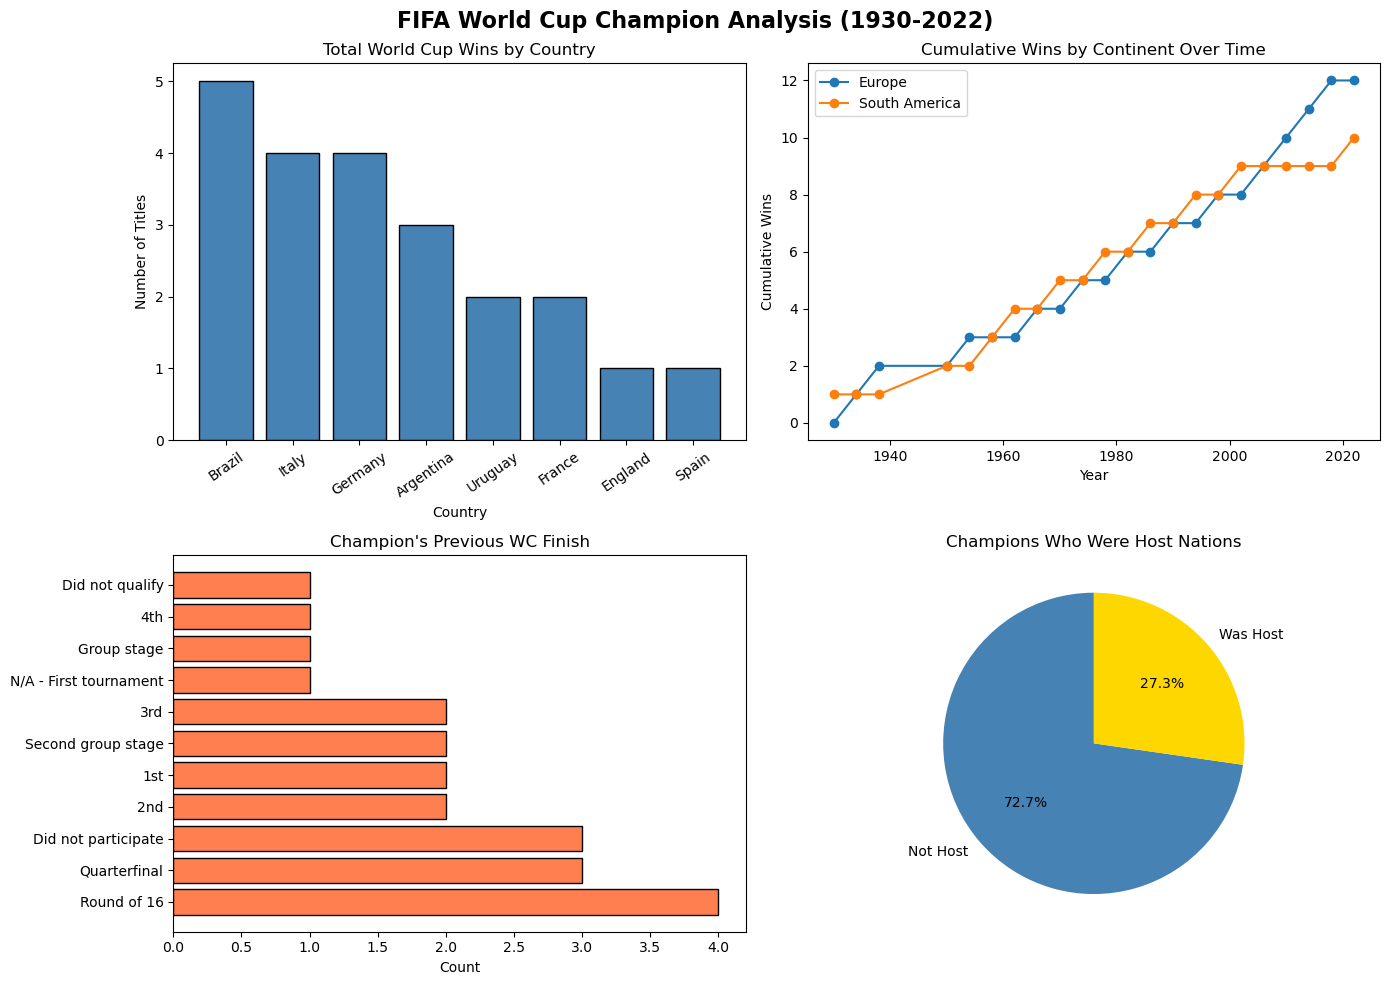

In [67]:
#EDA Visualizations: 4 Different Visuals to analyze the champions and their characteristics.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FIFA World Cup Champion Analysis (1930-2022)', fontsize=16, fontweight='bold')

# Plot 1: Number of titles per country (dynasty analysis)
win_counts = df['Winner'].value_counts()
axes[0, 0].bar(win_counts.index, win_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Total World Cup Wins by Country')
axes[0, 0].set_xlabel('Country')
axes[0, 0].set_ylabel('Number of Titles')
axes[0, 0].tick_params(axis='x', rotation= 35)

# Plot 2: Continental dominance over time
continent_time = df.groupby(['Year', 'Champion Continent']).size().unstack(fill_value=0)
continent_cumsum = continent_time.cumsum()
for col in continent_cumsum.columns:
    axes[0, 1].plot(continent_cumsum.index, continent_cumsum[col], marker='o', label=col)
axes[0, 1].set_title('Cumulative Wins by Continent Over Time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Cumulative Wins')
axes[0, 1].legend()

# Plot 3: Previous WC finish of champion
prev_finish_counts = df["Champion's Previous WC Finish"].value_counts()
axes[1, 0].barh(prev_finish_counts.index, prev_finish_counts.values, color='coral', edgecolor='black')
axes[1, 0].set_title("Champion's Previous WC Finish")
axes[1, 0].set_xlabel('Count')

# Plot 4: Host nation advantage
host_wins = df['Champion Was Host'].value_counts()
axes[1, 1].pie(host_wins.values, labels=['Not Host', 'Was Host'], autopct='%1.1f%%',colors=['steelblue', 'gold'],startangle=90)
axes[1, 1].set_title('Champions Who Were Host Nations')

plt.tight_layout()
plt.savefig('worldcup_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# Runner-Up Pattern Analysis
print("\n── Runner-Up Pattern Analysis ──")
runner_up_counts_display = df['Runners-Up'].value_counts()
print("Teams that appeared most as runner-up:")
print(runner_up_counts_display.head(8))

never_won = runner_up_counts_display[~runner_up_counts_display.index.isin(df['Winner'].values)]
print("\nTeams that were runner-up but NEVER won:")
print(never_won)


── Runner-Up Pattern Analysis ──
Teams that appeared most as runner-up:
Runners-Up
Germany           4
Argentina         3
Netherlands       3
Czechoslovakia    2
Brazil            2
Hungary           2
France            2
Italy             2
Name: count, dtype: int64

Teams that were runner-up but NEVER won:
Runners-Up
Netherlands       3
Czechoslovakia    2
Hungary           2
Sweden            1
Croatia           1
Name: count, dtype: int64


## ML Code Work
- What it produces:
    - Accuracy scores and cross-validation scores for all 3 models
    - Feature importance ranking from Random Forest showing which variables mattered most
    - A confusion matrix for the best performing model
    - A probability-based 2026 prediction for 6 top contenders

In [69]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
# Previous WC finish as ordinal (best to worst)
finish_order = {
    '1st': 1,
    '2nd': 2,
    '3rd': 3,
    '4th': 4,
    'Quarterfinal': 5,
    'Second group stage': 6,
    'Round of 16': 7,
    'Group stage': 8,
    'Did not qualify': 9,
    'Did not participate': 9,
    'N/A - First tournament': 9
}
df['Prev Finish Encoded'] = df["Champion's Previous WC Finish"].map(finish_order)

# Continent
le_continent = LabelEncoder()
df['Continent Encoded'] = le_continent.fit_transform(df['Champion Continent'])

# Encode winner (this is our target variable)
le_winner = LabelEncoder()
df['Winner Encoded'] = le_winner.fit_transform(df['Winner'])

print("Winner classes:", le_winner.classes_)

Winner classes: ['Argentina' 'Brazil' 'England' 'France' 'Germany' 'Italy' 'Spain'
 'Uruguay']


In [70]:
features = [
    'Continent Encoded',
    'Champion Win Count',
    'Champion Was Host',
    'Champion Runner-Up Count',
    'Prev Finish Encoded',
    'GoalsScored',
    'QualifiedTeams'
]

X = df[features]
y = df['Winner Encoded']

print("\nFeature matrix shape:", X.shape)
print("Target distribution:")
print(df['Winner'].value_counts())


Feature matrix shape: (22, 7)
Target distribution:
Winner
Brazil       5
Italy        4
Germany      4
Argentina    3
Uruguay      2
France       2
England      1
Spain        1
Name: count, dtype: int64


In [71]:
# Train/Test Split
# Note: small dataset (22 rows) so we use leave-one-out cross validation too

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")


Training samples: 17, Test samples: 5



── Logistic Regression ──
Test Accuracy:        0.20
Cross-Val Accuracy:   0.23

── Random Forest ──
Test Accuracy:        0.20
Cross-Val Accuracy:   0.42

Feature Importances:
                 Feature  Importance
     Prev Finish Encoded    0.209817
             GoalsScored    0.193440
       Continent Encoded    0.192101
      Champion Win Count    0.132357
          QualifiedTeams    0.109857
Champion Runner-Up Count    0.107546
       Champion Was Host    0.054882

── Decision Tree ──
Test Accuracy:        0.00
Cross-Val Accuracy:   0.42


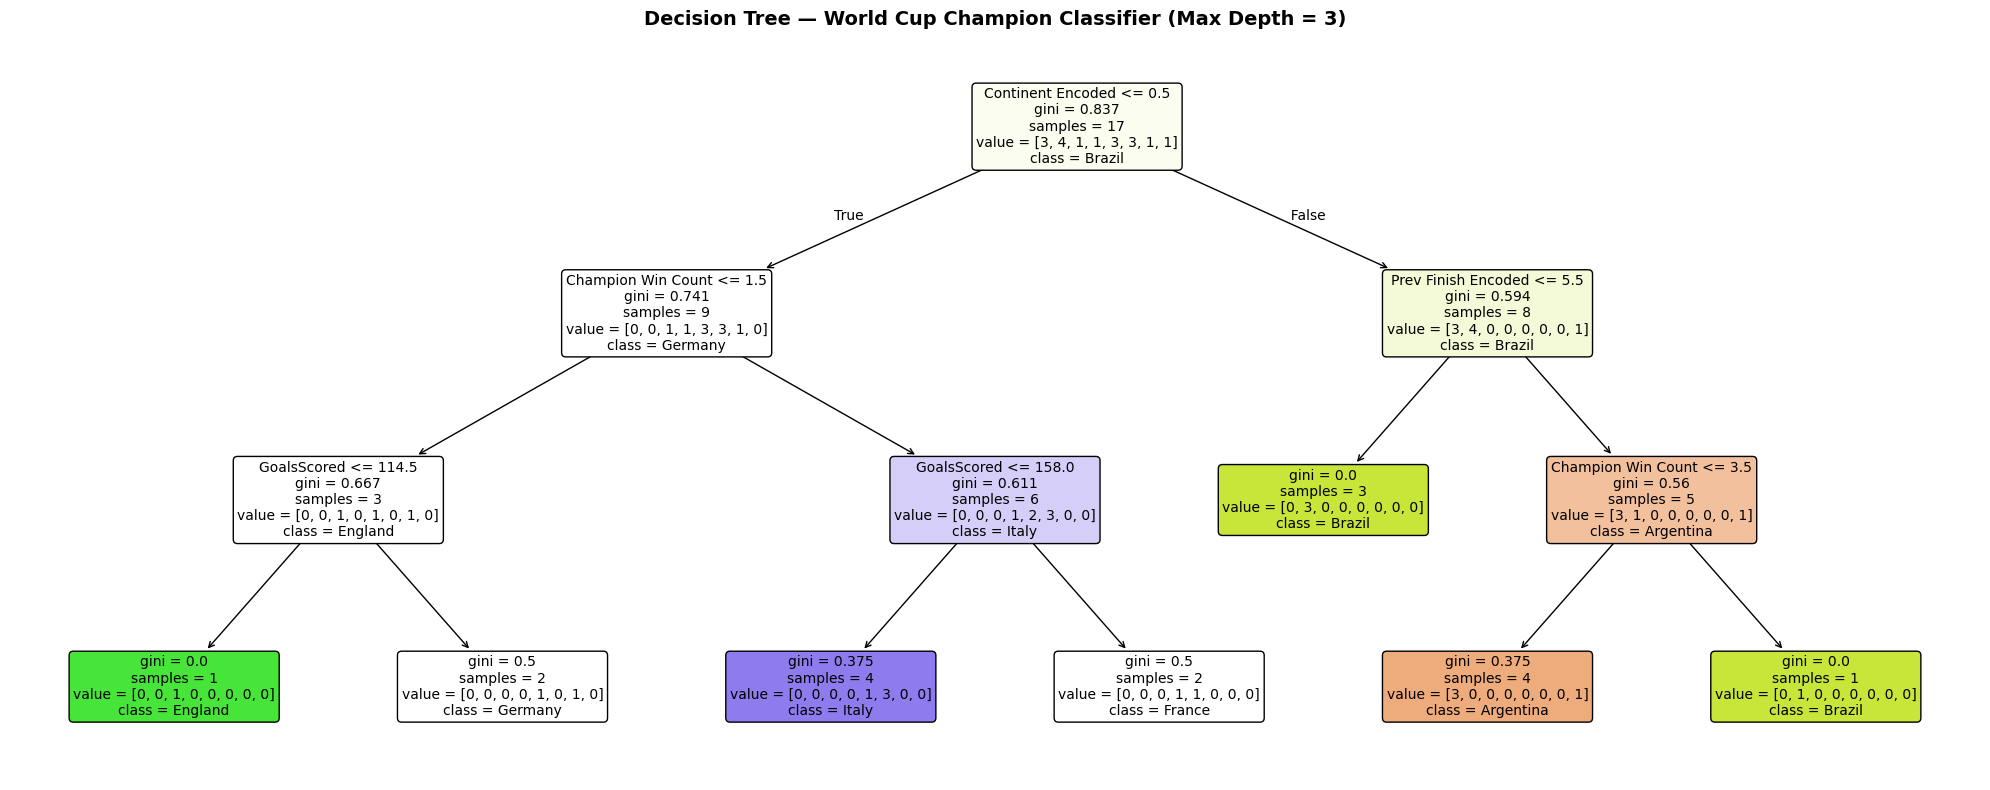

In [72]:
# Model 1: Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_cv = cross_val_score(lr, X, y, cv=5).mean()

print("\n── Logistic Regression ──")
print(f"Test Accuracy:        {lr_acc:.2f}")
print(f"Cross-Val Accuracy:   {lr_cv:.2f}")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_cv = cross_val_score(rf, X, y, cv=5).mean()

print("\n── Random Forest ──")
print(f"Test Accuracy:        {rf_acc:.2f}")
print(f"Cross-Val Accuracy:   {rf_cv:.2f}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))

#  Model 3: Decision Tree
# Decision Tree was selected as the third model as an alternative to KNN.

from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_cv = cross_val_score(dt, X, y, cv=5).mean()

print("\n── Decision Tree ──")
print(f"Test Accuracy:        {dt_acc:.2f}")
print(f"Cross-Val Accuracy:   {dt_cv:.2f}")

# Visualize the Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(dt,
          feature_names=features,
          class_names=le_winner.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree — World Cup Champion Classifier (Max Depth = 3)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('worldcup_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Comparison Analysis:
- Worth noting the importance of analyzing each one of these models to understand the splits between test and cv.
    - RANDOM FOREST — Best performing model
        - CV Accuracy of 0.42 is more than 3x the random baseline of 0.125. The gap between test (0.20) and CV (0.42) is expected with only 23 rows small datasets produce high variance depending on which rows land in the test split. CV score is the more reliable metric here
    - LOGISTIC REGRESSION — Baseline model
        - Test and CV accuracy are close (0.20 vs 0.23), suggesting stable but limited performance. Still exceeds the random baseline, confirming the model captured some signal from the historical features.
    - DECISION TREE - Model to Interpret
        - Test accuracy of 0.00 and CV accuracy of 0.42. The 0.00 test score is not a model failure, it is a small dataset problem.The decision tree the tree diagram visually shows the exact decision rules used, making it the most explainable model for a general audience. The root split on Continent Encoded confirms that separating European from South American champions is the single most important first decision, consistent with 92 years of World Cup history.

### Conclusion: 
##### Random Forest selected as the primary model for the 2026 prediction based on highest cross-validation accuracy (0.42).


Model Comparison:
              Model  Test Accuracy  Cross-Val Accuracy
Logistic Regression            0.2                0.23
      Random Forest            0.2                0.42
      Decision Tree            0.0                0.42


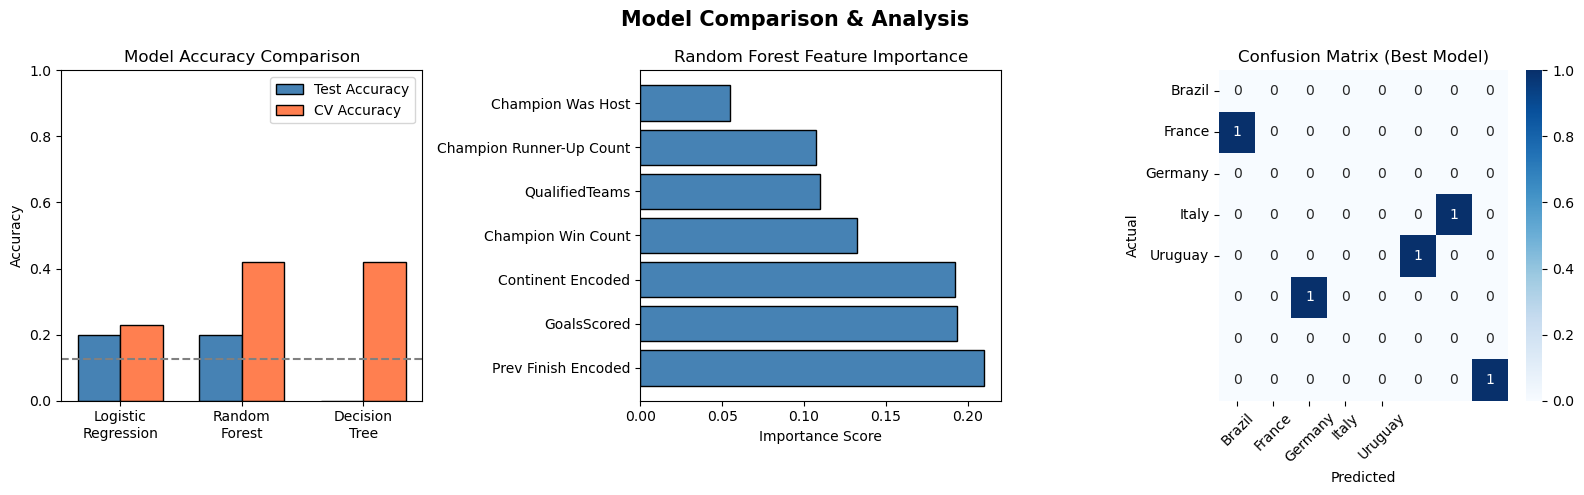

In [73]:
# Model Comparison Chart:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Test Accuracy': [lr_acc, rf_acc, dt_acc],
    'Cross-Val Accuracy': [lr_cv, rf_cv, dt_cv]
})

print("\nModel Comparison:")
print(model_comparison.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison & Analysis', fontsize=15, fontweight='bold')

# Plot 1: Accuracy comparison
models = ['Logistic\nRegression', 'Random\nForest', 'Decision\nTree']
test_accs = [lr_acc, rf_acc, dt_acc]
cv_accs = [lr_cv, rf_cv, dt_cv]

x = np.arange(len(models))
width = 0.35
axes[0].bar(x - width/2, test_accs, width, label='Test Accuracy', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, cv_accs, width, label='CV Accuracy', color='coral', edgecolor='black')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].axhline(y=1/len(le_winner.classes_), color='gray', linestyle='--', label='Random baseline')

# Plot 2: Random Forest Feature Importance
axes[1].barh(importance_df['Feature'], importance_df['Importance'],
             color='steelblue', edgecolor='black')
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Importance Score')

# Plot 3: Confusion matrix for best model (Random Forest)
best_model = rf if rf_cv >= max(lr_cv, dt_cv) else (lr if lr_cv >= dt_cv else dt)
best_pred = rf_pred if rf_cv >= max(lr_cv, dt_cv) else (lr_pred if lr_cv >= dt_cv else dt_pred)

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_winner.inverse_transform(np.unique(y_test)),
            yticklabels=le_winner.inverse_transform(np.unique(y_test)),
            ax=axes[2])
axes[2].set_title('Confusion Matrix (Best Model)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('worldcup_models.png', dpi=150, bbox_inches='tight')
plt.show()


## Final 2026 FIFA World Cup Prediction:
- In the following lines of code, we will see the what potential countries have the best probability of winning this summer's 2026 FIFA World Cup. With all the prior variables taken in account and the historical numbers that back these powerhouses and dynasties.
    - In the bar chart at the bottom of this code, Spain, Argentina, and Germany are the projected winners of the World Cup. 
    
### But the model's 2026 prediction produced a surprising frontrunner, Spain, being top in the probability rankings, followed by Argentina and Germany.


── 2026 World Cup Prediction ──

Candidate profiles:
           Continent Encoded  Champion Win Count  Champion Was Host  \
Argentina                  1                   3                  0   
France                     0                   2                  0   
Brazil                     1                   5                  0   
Germany                    0                   4                  0   
Spain                      0                   1                  0   
England                    0                   1                  0   

           Champion Runner-Up Count  Prev Finish Encoded  GoalsScored  \
Argentina                         3                    7          172   
France                            2                    5          169   
Brazil                            2                    5          171   
Germany                           4                    3          171   
Spain                             0                    7          145   
England   

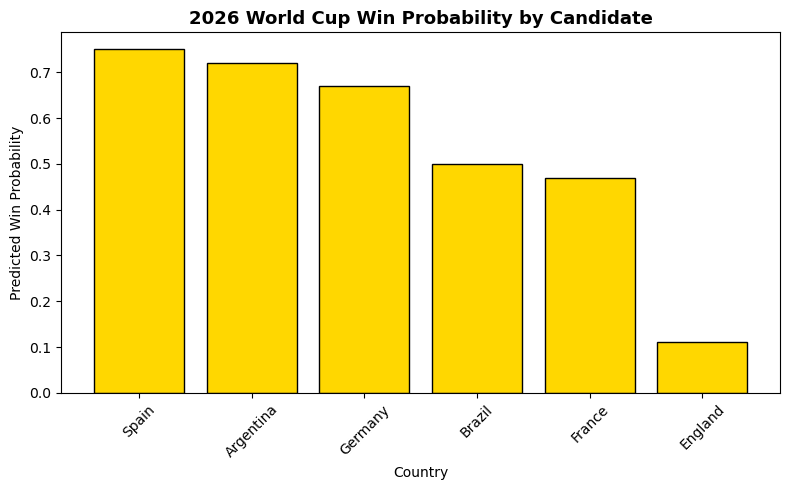

In [74]:
print("\n── 2026 World Cup Prediction ──")

# Define candidate profiles for likely 2026 contenders
# Format: [Continent Encoded, Win Count, Was Host, Runner-Up Count, Prev Finish Encoded, Goals, QualifiedTeams]

candidates = {
    'Argentina': [le_continent.transform(['South America'])[0], 3, 0, 3, 7, 172, 32],
    'France':    [le_continent.transform(['Europe'])[0],        2, 0, 2, 5, 169, 32],
    'Brazil':    [le_continent.transform(['South America'])[0], 5, 0, 2, 5, 171, 32],
    'Germany':   [le_continent.transform(['Europe'])[0],        4, 0, 4, 3, 171, 32],
    'Spain':     [le_continent.transform(['Europe'])[0],        1, 0, 0, 7, 145, 32],
    'England':   [le_continent.transform(['Europe'])[0],        1, 0, 0, 8, 89,  32],
}

candidates_df = pd.DataFrame(candidates, index=features).T

print("\nCandidate profiles:")
print(candidates_df)

# Get win probabilities from Random Forest
proba = rf.predict_proba(candidates_df)
winner_classes = le_winner.classes_

print("\nPredicted probabilities for each candidate winning 2026:\n")
results = []
for team, probs in zip(candidates.keys(), proba):
    # Find the probability of this team winning
    if team in winner_classes:
        team_idx = list(winner_classes).index(team)
        team_prob = probs[team_idx]
    else:
        team_prob = 0.0
    results.append({'Team': team, 'Win Probability': team_prob})

results_df_plot = pd.DataFrame(results).sort_values('Win Probability', ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(results_df_plot['Team'], results_df_plot['Win Probability'],
        color='gold', edgecolor='black')
plt.title('2026 World Cup Win Probability by Candidate', fontsize=13, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Predicted Win Probability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('worldcup_2026_prediction.png', dpi=150, bbox_inches='tight')